In [4]:
from pathlib import Path
import json

import nibabel as nib
import numpy as np
from scipy import ndimage as ndi


def make_elliptical_footprint(
    radius_mm: float,
    spacing_2d_mm: tuple[float, float],
) -> np.ndarray:
    if radius_mm <= 0:
        return np.ones((1, 1), dtype=bool)

    r0 = int(np.ceil(radius_mm / spacing_2d_mm[0]))
    r1 = int(np.ceil(radius_mm / spacing_2d_mm[1]))

    g0, g1 = np.ogrid[-r0:r0 + 1, -r1:r1 + 1]

    return (
        (g0 * spacing_2d_mm[0]) ** 2
        + (g1 * spacing_2d_mm[1]) ** 2
        <= radius_mm**2
    )


def correct_affine_spacing(
    affine: np.ndarray,
    spacing_mm: tuple[float, float, float],
) -> np.ndarray:
    """
    Preserve the orientation and origin while replacing the incorrect
    voxel spacing stored in the affine.
    """
    new_affine = affine.copy().astype(np.float64)
    direction = new_affine[:3, :3].copy()

    norms = np.linalg.norm(direction, axis=0)

    for axis in range(3):
        if norms[axis] > 0:
            direction[:, axis] /= norms[axis]
        else:
            direction[:, axis] = 0
            direction[axis, axis] = 1

    new_affine[:3, :3] = direction * np.asarray(spacing_mm)[None, :]

    return new_affine


def find_marker_selected_2d_component(
    tooth_mask,
    marker_mask,
    spacing_mm,
    annotation_axis=2,
    marker_tolerance_mm=2.0,
):
    """
    점이 위치한 slice에서 관심 치아의 2D component를 선택합니다.

    annotation_axis=2:
        axial slice에서 치아를 선택한 뒤 z축 방향으로 추적
    """
    marker_coordinates = np.argwhere(marker_mask)

    if marker_coordinates.size == 0:
        raise ValueError("Marker mask contains no positive voxels.")

    marker_center = marker_coordinates.mean(axis=0)

    # 점의 중심과 가장 가까운 slice
    reference_slice = int(
        np.round(marker_center[annotation_axis])
    )

    reference_slice = np.clip(
        reference_slice,
        0,
        tooth_mask.shape[annotation_axis] - 1,
    )

    tooth_plane = np.take(
        tooth_mask,
        reference_slice,
        axis=annotation_axis,
    )

    marker_plane = np.take(
        marker_mask,
        reference_slice,
        axis=annotation_axis,
    )

    # 2D에서는 모서리 접촉을 연결하지 않도록 4-connectivity 사용
    component_labels, number_of_components = ndi.label(
        tooth_plane,
        structure=ndi.generate_binary_structure(2, 1),
    )

    if number_of_components == 0:
        raise ValueError(
            "No tooth component exists on the marker slice."
        )

    # 점과 직접 겹치는 component 확인
    overlapping_labels = component_labels[marker_plane]
    overlapping_labels = overlapping_labels[
        overlapping_labels > 0
    ]

    if overlapping_labels.size > 0:
        selected_label = int(
            np.bincount(overlapping_labels).argmax()
        )
        selection_method = "2d_direct_overlap"

    else:
        # 점이 segmentation과 정확히 겹치지 않으면
        # 점에서 가장 가까운 2D component 선택
        plane_axes = [
            axis for axis in range(3)
            if axis != annotation_axis
        ]

        marker_center_2d = marker_center[plane_axes]
        spacing_2d = np.asarray(spacing_mm)[plane_axes]

        best_label = None
        best_distance = np.inf

        for label_id in range(1, number_of_components + 1):
            component_coordinates = np.argwhere(
                component_labels == label_id
            )

            if component_coordinates.size == 0:
                continue

            distances_mm = np.sqrt(
                np.sum(
                    (
                        (
                            component_coordinates
                            - marker_center_2d
                        )
                        * spacing_2d
                    ) ** 2,
                    axis=1,
                )
            )

            minimum_distance = float(distances_mm.min())

            if minimum_distance < best_distance:
                best_distance = minimum_distance
                best_label = label_id

        if (
            best_label is None
            or best_distance > marker_tolerance_mm
        ):
            raise ValueError(
                "No tooth component was found within "
                f"{marker_tolerance_mm} mm of the marker."
            )

        selected_label = int(best_label)
        selection_method = "2d_nearest_component"

    reference_component = (
        component_labels == selected_label
    )

    return {
        "reference_component": reference_component,
        "reference_slice": reference_slice,
        "annotation_axis": annotation_axis,
        "marker_center": marker_center,
        "selection_method": selection_method,
    }


def extract_target_tooth(
    segmentation,
    marker_mask,
    tooth_label,
    spacing_mm,
    marker_tolerance_mm,
    annotation_axis=2,
    projection_margin_mm=1.0,
):
    """
    1. Marker slice에서 관심 치아의 2D component를 선택
    2. 선택된 위치를 annotation axis 방향으로 projection
    3. Projection 내부의 tooth voxels만 남김
    4. Reference component와 연결된 3D component만 선택
    """
    tooth_mask = segmentation == tooth_label

    if not np.any(tooth_mask):
        raise ValueError(
            f"Tooth label {tooth_label} does not exist."
        )

    reference_result = find_marker_selected_2d_component(
        tooth_mask=tooth_mask,
        marker_mask=marker_mask,
        spacing_mm=spacing_mm,
        annotation_axis=annotation_axis,
        marker_tolerance_mm=marker_tolerance_mm,
    )

    reference_component = reference_result[
        "reference_component"
    ]
    reference_slice = reference_result[
        "reference_slice"
    ]
    marker_center = reference_result["marker_center"]

    plane_axes = [
        axis for axis in range(3)
        if axis != annotation_axis
    ]

    spacing_2d = (
        spacing_mm[plane_axes[0]],
        spacing_mm[plane_axes[1]],
    )

    # Reference tooth component로부터 물리적 거리 계산
    distance_from_reference_mm = ndi.distance_transform_edt(
        ~reference_component,
        sampling=spacing_2d,
    )

    # 치아가 z축을 따라 약간 이동하거나 기울어진 경우를 허용
    projected_support = (
        distance_from_reference_mm
        <= projection_margin_mm
    )

    # 2D support를 3D 전체 방향으로 projection
    support_3d = np.zeros_like(
        tooth_mask,
        dtype=bool,
    )

    if annotation_axis == 0:
        support_3d[:] = projected_support[None, :, :]

    elif annotation_axis == 1:
        support_3d[:] = projected_support[:, None, :]

    elif annotation_axis == 2:
        support_3d[:] = projected_support[:, :, None]

    else:
        raise ValueError(
            "annotation_axis must be 0, 1, or 2."
        )

    # 관심 치아가 존재할 수 있는 좁은 위치만 유지
    candidate_mask = tooth_mask & support_3d

    # 6-connectivity로 3D component 계산
    component_labels, number_of_components = ndi.label(
        candidate_mask,
        structure=ndi.generate_binary_structure(3, 1),
    )

    if number_of_components == 0:
        raise ValueError(
            "No target-tooth candidate was found."
        )

    # Reference slice에서 선택했던 2D component와
    # 가장 많이 겹치는 3D component 선택
    component_plane = np.take(
        component_labels,
        reference_slice,
        axis=annotation_axis,
    )

    intersecting_labels = component_plane[
        reference_component
    ]

    intersecting_labels = intersecting_labels[
        intersecting_labels > 0
    ]

    if intersecting_labels.size == 0:
        raise ValueError(
            "The 3D candidate did not intersect "
            "the selected 2D tooth component."
        )

    selected_component = int(
        np.bincount(intersecting_labels).argmax()
    )

    target_tooth = (
        component_labels == selected_component
    )

    target_coordinates = np.argwhere(target_tooth)

    if target_coordinates.size == 0:
        raise ValueError(
            "The extracted target-tooth mask is empty."
        )

    bbox_start = target_coordinates.min(axis=0)
    bbox_end = target_coordinates.max(axis=0) + 1

    tooth_size_mm = (
        (bbox_end - bbox_start)
        * np.asarray(spacing_mm)
    )

    return {
        "target_tooth": target_tooth,
        "marker_center_voxel": marker_center,
        "selection_method": (
            reference_result["selection_method"]
            + "_with_3d_projection"
        ),
        "reference_slice": reference_slice,
        "annotation_axis": annotation_axis,
        "tooth_bbox_start": bbox_start,
        "tooth_bbox_end": bbox_end,
        "tooth_size_mm": tooth_size_mm,
    }


def calculate_roi_bounds(
    target_tooth: np.ndarray,
    spacing_mm: tuple[float, float, float],
    buccolingual_axis: int = 0,
    mesiodistal_axis: int = 1,
    apico_occlusal_axis: int = 2,
    apical_sign: int = 1,
    mesial_distal_margin_mm: float = 1.5,
    buccolingual_margin_mm: float = 1.5,
    occlusal_margin_mm: float = 1.5,
    apical_margin_mm: float = 4.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    apical_sign = +1:
        Increasing voxel index is the apical direction.

    apical_sign = -1:
        Decreasing voxel index is the apical direction.
    """
    if apical_sign not in (-1, 1):
        raise ValueError("apical_sign must be either +1 or -1.")

    axes = {
        buccolingual_axis,
        mesiodistal_axis,
        apico_occlusal_axis,
    }

    if axes != {0, 1, 2}:
        raise ValueError(
            "The three anatomical axes must be a permutation of 0, 1, and 2."
        )

    coordinates = np.argwhere(target_tooth)

    if coordinates.size == 0:
        raise ValueError("The extracted target-tooth mask is empty.")

    lower = coordinates.min(axis=0).astype(int)
    upper = (coordinates.max(axis=0) + 1).astype(int)

    spacing = np.asarray(spacing_mm, dtype=float)

    buccolingual_margin_voxels = int(
        np.ceil(
            buccolingual_margin_mm
            / spacing[buccolingual_axis]
        )
    )

    mesiodistal_margin_voxels = int(
        np.ceil(
            mesial_distal_margin_mm
            / spacing[mesiodistal_axis]
        )
    )

    occlusal_margin_voxels = int(
        np.ceil(
            occlusal_margin_mm
            / spacing[apico_occlusal_axis]
        )
    )

    apical_margin_voxels = int(
        np.ceil(
            apical_margin_mm
            / spacing[apico_occlusal_axis]
        )
    )

    lower[buccolingual_axis] -= buccolingual_margin_voxels
    upper[buccolingual_axis] += buccolingual_margin_voxels

    lower[mesiodistal_axis] -= mesiodistal_margin_voxels
    upper[mesiodistal_axis] += mesiodistal_margin_voxels

    if apical_sign == 1:
        lower[apico_occlusal_axis] -= occlusal_margin_voxels
        upper[apico_occlusal_axis] += apical_margin_voxels
    else:
        lower[apico_occlusal_axis] -= apical_margin_voxels
        upper[apico_occlusal_axis] += occlusal_margin_voxels

    lower = np.maximum(lower, 0)
    upper = np.minimum(
        upper,
        np.asarray(target_tooth.shape),
    )

    return lower, upper


def crop_affine(
    affine: np.ndarray,
    crop_start: np.ndarray,
) -> np.ndarray:
    new_affine = affine.copy()

    new_origin = affine @ np.array(
        [
            crop_start[0],
            crop_start[1],
            crop_start[2],
            1,
        ],
        dtype=float,
    )

    new_affine[:3, 3] = new_origin[:3]

    return new_affine


def resample_array(
    array: np.ndarray,
    source_spacing_mm: tuple[float, float, float],
    target_spacing_mm: tuple[float, float, float],
    interpolation_order: int,
) -> np.ndarray:
    source_spacing = np.asarray(source_spacing_mm, dtype=float)
    target_spacing = np.asarray(target_spacing_mm, dtype=float)

    if np.allclose(source_spacing, target_spacing):
        return array

    zoom_factors = source_spacing / target_spacing

    return ndi.zoom(
        array,
        zoom=zoom_factors,
        order=interpolation_order,
        mode="nearest",
        prefilter=False,
    )


def calculate_padding(
    current_shape: tuple[int, int, int],
    target_shape: tuple[int, int, int],
    apico_occlusal_axis: int,
    apical_sign: int,
    align_apical_boundary: bool = True,
) -> tuple[tuple[int, int], ...]:
    current_shape = np.asarray(current_shape)
    target_shape = np.asarray(target_shape)

    extra = target_shape - current_shape

    if np.any(extra < 0):
        raise ValueError(
            f"Target shape {tuple(target_shape)} is smaller than "
            f"the current crop {tuple(current_shape)}."
        )

    padding = []

    for axis in range(3):
        axis_extra = int(extra[axis])

        if (
            align_apical_boundary
            and axis == apico_occlusal_axis
        ):
            if apical_sign == 1:
                before = axis_extra
                after = 0
            else:
                before = 0
                after = axis_extra
        else:
            before = axis_extra // 2
            after = axis_extra - before

        padding.append((before, after))

    return tuple(padding)


def pad_affine(
    affine: np.ndarray,
    padding: tuple[tuple[int, int], ...],
) -> np.ndarray:
    before_padding = np.array(
        [padding[axis][0] for axis in range(3)],
        dtype=float,
    )

    new_affine = affine.copy()

    new_origin = affine @ np.array(
        [
            -before_padding[0],
            -before_padding[1],
            -before_padding[2],
            1,
        ]
    )

    new_affine[:3, 3] = new_origin[:3]

    return new_affine


def save_nifti(
    array: np.ndarray,
    affine: np.ndarray,
    output_path: str | Path,
    spacing_mm: tuple[float, float, float],
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    output_nifti = nib.Nifti1Image(array, affine)
    output_nifti.set_qform(affine, code=1)
    output_nifti.set_sform(affine, code=1)
    output_nifti.header.set_zooms(spacing_mm)

    nib.save(output_nifti, output_path)


def create_tooth_centered_roi(
    image_path: str | Path,
    segmentation_path: str | Path,
    marker_path: str | Path,
    output_prefix: str | Path,
    source_spacing_mm: tuple[float, float, float],
    target_spacing_mm: tuple[float, float, float] | None = None,
    target_shape: tuple[int, int, int] | None = None,
    tooth_label: int = 4,
    annotation_axis: int | None = None,
    buccolingual_axis: int = 0,
    mesiodistal_axis: int = 1,
    apico_occlusal_axis: int = 2,
    apical_sign: int = 1,
    projection_margin_mm: float = 1.0,
    tooth_search_radius_mm: float = 15.0,
    mesial_distal_margin_mm: float = 2.5,
    buccolingual_margin_mm: float = 2.5,
    occlusal_margin_mm: float = 2.5,
    apical_margin_mm: float = 5.0,
    image_padding_value: float = 0.0,
) -> dict:
    image_nifti = nib.load(str(image_path))
    segmentation_nifti = nib.load(str(segmentation_path))
    marker_nifti = nib.load(str(marker_path))

    image = np.asanyarray(image_nifti.dataobj)
    segmentation = np.rint(
        np.asanyarray(segmentation_nifti.dataobj)
    ).astype(np.int16)
    marker_mask = np.asanyarray(marker_nifti.dataobj) > 0

    if not (
        image.shape
        == segmentation.shape
        == marker_mask.shape
    ):
        raise ValueError(
            "Image, segmentation, and marker shapes are different."
        )

    source_spacing_mm = tuple(
        float(value) for value in source_spacing_mm
    )

    if target_spacing_mm is None:
        target_spacing_mm = source_spacing_mm
    else:
        target_spacing_mm = tuple(
            float(value) for value in target_spacing_mm
        )

    corrected_affine = correct_affine_spacing(
        affine=image_nifti.affine,
        spacing_mm=source_spacing_mm,
    )

    tooth_mask = segmentation == tooth_label

    target_result = extract_target_tooth(
        segmentation=segmentation,
        marker_mask=marker_mask,
        tooth_label=TOOTH_LABEL,
        spacing_mm=SOURCE_SPACING_MM,
        marker_tolerance_mm=MARKER_TOLERANCE_MM,

        # axial plane에서 치아를 선택하고 z축 방향으로 추적
        annotation_axis=2,

        # 치아 기울기와 segmentation 변동 허용 범위
        projection_margin_mm=1.0,
    )
    target_coordinates = np.argwhere(target_tooth)
    target_bbox_lower = target_coordinates.min(axis=0)
    target_bbox_upper = target_coordinates.max(axis=0) + 1

    crop_lower, crop_upper = calculate_roi_bounds(
        target_tooth=target_tooth,
        spacing_mm=source_spacing_mm,
        buccolingual_axis=buccolingual_axis,
        mesiodistal_axis=mesiodistal_axis,
        apico_occlusal_axis=apico_occlusal_axis,
        apical_sign=apical_sign,
        mesial_distal_margin_mm=mesial_distal_margin_mm,
        buccolingual_margin_mm=buccolingual_margin_mm,
        occlusal_margin_mm=occlusal_margin_mm,
        apical_margin_mm=apical_margin_mm,
    )

    crop_slices = tuple(
        slice(int(crop_lower[axis]), int(crop_upper[axis]))
        for axis in range(3)
    )

    cropped_image = image[crop_slices]
    cropped_segmentation = segmentation[crop_slices]
    cropped_target_tooth = target_tooth[crop_slices].astype(np.uint8)

    output_affine = crop_affine(
        affine=corrected_affine,
        crop_start=crop_lower,
    )

    cropped_image = resample_array(
        array=cropped_image,
        source_spacing_mm=source_spacing_mm,
        target_spacing_mm=target_spacing_mm,
        interpolation_order=1,
    ).astype(np.float32)

    cropped_segmentation = resample_array(
        array=cropped_segmentation,
        source_spacing_mm=source_spacing_mm,
        target_spacing_mm=target_spacing_mm,
        interpolation_order=0,
    ).astype(np.int16)

    cropped_target_tooth = resample_array(
        array=cropped_target_tooth,
        source_spacing_mm=source_spacing_mm,
        target_spacing_mm=target_spacing_mm,
        interpolation_order=0,
    ).astype(np.uint8)

    output_affine = correct_affine_spacing(
        affine=output_affine,
        spacing_mm=target_spacing_mm,
    )

    shape_before_padding = tuple(cropped_image.shape)

    if target_shape is not None:
        padding = calculate_padding(
            current_shape=cropped_image.shape,
            target_shape=target_shape,
            apico_occlusal_axis=apico_occlusal_axis,
            apical_sign=apical_sign,
            align_apical_boundary=True,
        )

        cropped_image = np.pad(
            cropped_image,
            pad_width=padding,
            mode="constant",
            constant_values=image_padding_value,
        )

        cropped_segmentation = np.pad(
            cropped_segmentation,
            pad_width=padding,
            mode="constant",
            constant_values=0,
        )

        cropped_target_tooth = np.pad(
            cropped_target_tooth,
            pad_width=padding,
            mode="constant",
            constant_values=0,
        )

        output_affine = pad_affine(
            affine=output_affine,
            padding=padding,
        )

    output_prefix = Path(output_prefix)

    image_output_path = Path(
        f"{output_prefix}_roi_img.nii.gz"
    )
    segmentation_output_path = Path(
        f"{output_prefix}_roi_seg.nii.gz"
    )
    tooth_output_path = Path(
        f"{output_prefix}_roi_target_tooth.nii.gz"
    )
    metadata_output_path = Path(
        f"{output_prefix}_roi_metadata.json"
    )

    save_nifti(
        array=cropped_image,
        affine=output_affine,
        output_path=image_output_path,
        spacing_mm=target_spacing_mm,
    )

    save_nifti(
        array=cropped_segmentation,
        affine=output_affine,
        output_path=segmentation_output_path,
        spacing_mm=target_spacing_mm,
    )

    save_nifti(
        array=cropped_target_tooth,
        affine=output_affine,
        output_path=tooth_output_path,
        spacing_mm=target_spacing_mm,
    )

    metadata = {
        "source_spacing_mm": list(source_spacing_mm),
        "target_spacing_mm": list(target_spacing_mm),
        "annotation_axis": int(detected_annotation_axis),
        "reference_slice": int(reference_slice),
        "target_tooth_bbox_start": target_bbox_lower.tolist(),
        "target_tooth_bbox_end_exclusive": target_bbox_upper.tolist(),
        "crop_start": crop_lower.tolist(),
        "crop_end_exclusive": crop_upper.tolist(),
        "shape_before_padding": list(shape_before_padding),
        "final_shape": list(cropped_image.shape),
        "apical_sign": int(apical_sign),
        "image_output": str(image_output_path),
        "segmentation_output": str(segmentation_output_path),
        "target_tooth_output": str(tooth_output_path),
    }

    metadata_output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with open(metadata_output_path, "w") as file:
        json.dump(metadata, file, indent=2)

    return metadata

In [5]:
metadata = create_tooth_centered_roi(
    image_path="../DSApre/DSA085pre_img.nii.gz",
    segmentation_path="../DSApre/seg/DSA085pre_img.nii.gz",
    marker_path="../DSApre/mask/85.nii.gz",
    output_prefix="../DSApre/roi_crop/DSA085pre_85_v2",

    # NIfTI header의 1 mm 대신 실제 DSA spacing 사용
    source_spacing_mm=(0.1, 0.1, 0.1),
    target_spacing_mm=(0.1, 0.1, 0.1),

    tooth_label=4,

    # 현재 파일의 좌표 방향
    buccolingual_axis=0,
    mesiodistal_axis=1,
    apico_occlusal_axis=2,

    # 현재 파일에서는 +z 방향이 root apex 방향
    apical_sign=1,

    projection_margin_mm=1.0,
    tooth_search_radius_mm=15.0,

    mesial_distal_margin_mm=1.5,
    buccolingual_margin_mm=1.5,
    occlusal_margin_mm=1.5,
    apical_margin_mm=4.0,

    # 첫 단계에서는 환자별 원래 ROI 크기로 저장
    target_shape=None,
)

print(metadata)

NameError: name 'target_tooth' is not defined

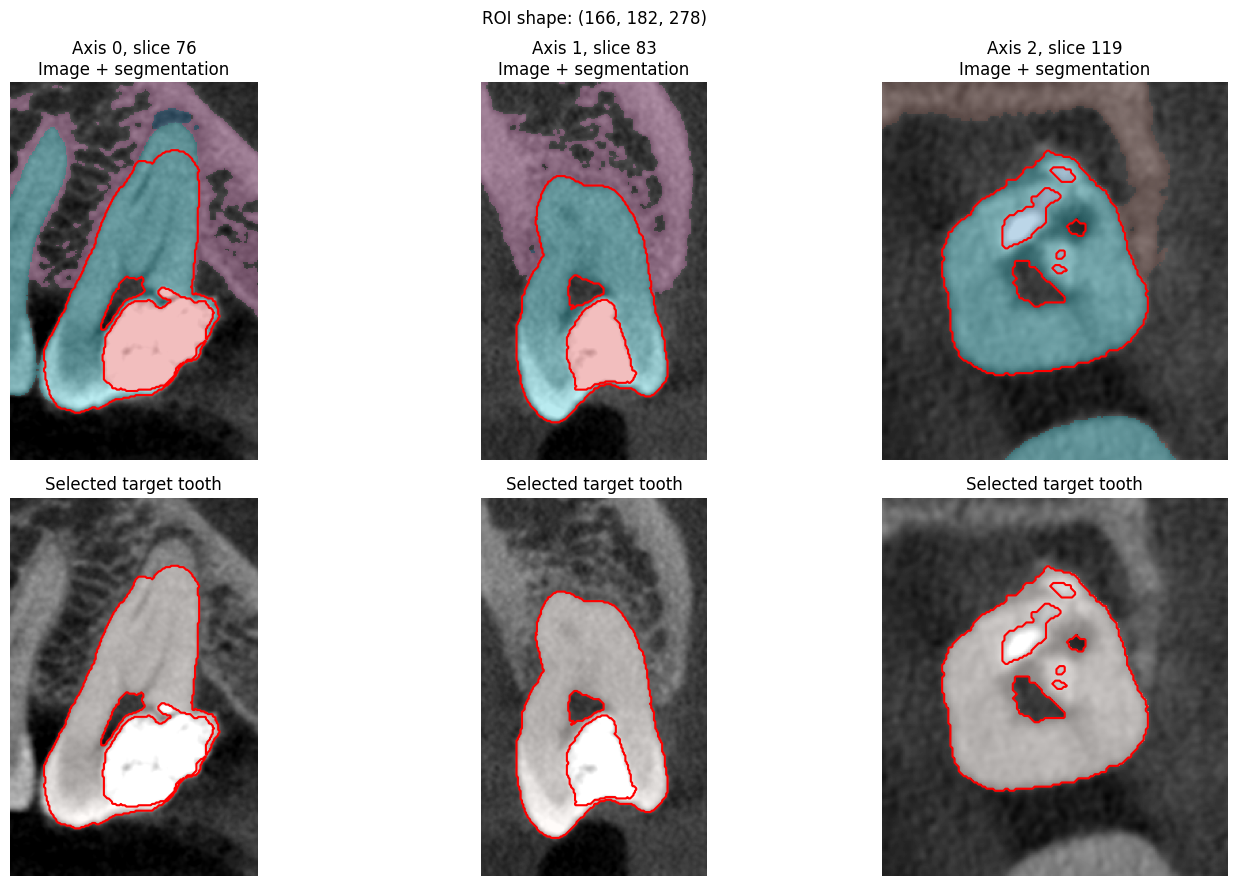

In [12]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


output_prefix = "../DSApre/roi_crop/DSA085pre_85"

image_path = f"{output_prefix}_roi_img.nii.gz"
seg_path = f"{output_prefix}_roi_seg.nii.gz"
tooth_path = f"{output_prefix}_roi_target_tooth.nii.gz"


image = np.asarray(nib.load(image_path).dataobj, dtype=np.float32)
seg = np.asarray(nib.load(seg_path).dataobj)
target_tooth = np.asarray(nib.load(tooth_path).dataobj) > 0


# Target tooth 중심 slice
coords = np.argwhere(target_tooth)

if len(coords) == 0:
    center = np.array(image.shape) // 2
else:
    center = np.round(coords.mean(axis=0)).astype(int)


vmin, vmax = np.percentile(image[np.isfinite(image)], [1, 99])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for axis in range(3):
    idx = center[axis]

    image_slice = np.rot90(np.take(image, idx, axis=axis))
    seg_slice = np.rot90(np.take(seg, idx, axis=axis))
    tooth_slice = np.rot90(np.take(target_tooth, idx, axis=axis))

    # CBCT와 전체 segmentation
    axes[0, axis].imshow(
        image_slice,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    axes[0, axis].imshow(
        np.ma.masked_where(seg_slice == 0, seg_slice),
        cmap="tab10",
        alpha=0.3,
        interpolation="nearest",
    )

    if tooth_slice.any():
        axes[0, axis].contour(
            tooth_slice,
            levels=[0.5],
            colors="red",
            linewidths=1.5,
        )

    axes[0, axis].set_title(
        f"Axis {axis}, slice {idx}\nImage + segmentation"
    )
    axes[0, axis].axis("off")

    # CBCT와 선택된 치아
    axes[1, axis].imshow(
        image_slice,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    if tooth_slice.any():
        axes[1, axis].imshow(
            np.ma.masked_where(~tooth_slice, tooth_slice),
            alpha=0.4,
            cmap="Reds",
            interpolation="nearest",
        )

        axes[1, axis].contour(
            tooth_slice,
            levels=[0.5],
            colors="red",
            linewidths=1.5,
        )

    axes[1, axis].set_title("Selected target tooth")
    axes[1, axis].axis("off")


plt.suptitle(f"ROI shape: {image.shape}")
plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
import csv
import gc
import json
import re

import nibabel as nib
import numpy as np
from scipy import ndimage as ndi


# =========================================================
# Configuration
# =========================================================

ROOT_DIR = Path("../DSApre")

IMAGE_DIR = ROOT_DIR
SEG_DIR = ROOT_DIR / "seg"
MASK_DIR = ROOT_DIR / "mask"
OUTPUT_DIR = ROOT_DIR / "roi_crop"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOOTH_LABEL = 4

# 실제 DSA voxel spacing
SOURCE_SPACING_MM = (0.1, 0.1, 0.1)

# 현재 영상 좌표계 기준
BUCCOLINGUAL_AXIS = 0
MESIODISTAL_AXIS = 1
APICO_OCCLUSAL_AXIS = 2

# +1: index가 증가하는 방향이 apical
# -1: index가 감소하는 방향이 apical
APICAL_SIGN = 1

MESIODISTAL_MARGIN_MM = 1.5
BUCCOLINGUAL_MARGIN_MM = 1.5
OCCLUSAL_MARGIN_MM = 1.5
APICAL_MARGIN_MM = 4.0

# 점이 tooth label과 정확히 겹치지 않을 때 허용 거리
MARKER_TOLERANCE_MM = 2.0

# 연결 component가 이보다 크면 여러 치아가 연결되었을 가능성을 경고
SUSPICIOUS_MD_SIZE_MM = 15.0
SUSPICIOUS_BL_SIZE_MM = 15.0
SUSPICIOUS_APICO_OCCLUSAL_SIZE_MM = 30.0


# =========================================================
# Filename handling
# =========================================================

def extract_case_number(filename):
    """
    DSA-106PRE_img.nii.gz -> 106
    DSA001pre_img.nii.gz -> 001
    """
    match = re.search(r"DSA-?(\d+)", filename, flags=re.IGNORECASE)

    if match is None:
        raise ValueError(f"Cannot extract DSA number from: {filename}")

    return match.group(1)


def remove_image_suffix(filename):
    return re.sub(
        r"_img\.nii(?:\.gz)?$",
        "",
        filename,
        flags=re.IGNORECASE,
    )


def find_marker_path(case_number):
    """
    가능한 mask 이름을 순서대로 확인합니다.

    001.nii.gz
    1.nii.gz
    001.nii
    1.nii
    """
    integer_number = int(case_number)

    candidates = [
        MASK_DIR / f"{case_number}.nii.gz",
        MASK_DIR / f"{integer_number}.nii.gz",
        MASK_DIR / f"{integer_number:03d}.nii.gz",
        MASK_DIR / f"{case_number}.nii",
        MASK_DIR / f"{integer_number}.nii",
        MASK_DIR / f"{integer_number:03d}.nii",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


# =========================================================
# NIfTI utilities
# =========================================================

def correct_affine_spacing(affine, spacing_mm):
    """
    기존 orientation과 origin을 유지하면서 spacing만 수정합니다.
    """
    corrected_affine = affine.copy().astype(np.float64)
    direction = corrected_affine[:3, :3].copy()

    norms = np.linalg.norm(direction, axis=0)

    for axis in range(3):
        if norms[axis] > 0:
            direction[:, axis] /= norms[axis]
        else:
            direction[:, axis] = 0
            direction[axis, axis] = 1

    corrected_affine[:3, :3] = (
        direction * np.asarray(spacing_mm)[None, :]
    )

    return corrected_affine


def create_crop_affine(affine, crop_start):
    cropped_affine = affine.copy()

    new_origin = affine @ np.array(
        [
            crop_start[0],
            crop_start[1],
            crop_start[2],
            1.0,
        ]
    )

    cropped_affine[:3, 3] = new_origin[:3]

    return cropped_affine


def save_nifti(array, affine, output_path, spacing_mm):
    output_nii = nib.Nifti1Image(array, affine)

    output_nii.set_qform(affine, code=1)
    output_nii.set_sform(affine, code=1)
    output_nii.header.set_zooms(spacing_mm)

    nib.save(output_nii, str(output_path))


# =========================================================
# Target tooth selection
# =========================================================

def find_nearest_tooth_voxel(
    tooth_mask,
    marker_center,
    spacing_mm,
    tolerance_mm,
):
    """
    Marker가 tooth mask와 직접 겹치지 않을 때 주변에서 가장 가까운
    tooth voxel을 찾습니다.
    """
    spacing = np.asarray(spacing_mm, dtype=float)

    radius_voxels = np.ceil(
        tolerance_mm / spacing
    ).astype(int)

    lower = np.maximum(
        np.floor(marker_center).astype(int) - radius_voxels,
        0,
    )

    upper = np.minimum(
        np.ceil(marker_center).astype(int) + radius_voxels + 1,
        np.asarray(tooth_mask.shape),
    )

    search_slices = tuple(
        slice(int(lower[axis]), int(upper[axis]))
        for axis in range(3)
    )

    local_tooth = tooth_mask[search_slices]
    local_coordinates = np.argwhere(local_tooth)

    if local_coordinates.size == 0:
        return None

    global_coordinates = local_coordinates + lower

    distances_mm = np.sqrt(
        np.sum(
            (
                (global_coordinates - marker_center)
                * spacing
            ) ** 2,
            axis=1,
        )
    )

    nearest_index = int(np.argmin(distances_mm))
    nearest_distance = float(distances_mm[nearest_index])

    if nearest_distance > tolerance_mm:
        return None

    return global_coordinates[nearest_index]


def find_marker_selected_2d_component(
    tooth_mask,
    marker_mask,
    spacing_mm,
    annotation_axis=2,
    marker_tolerance_mm=2.0,
):
    """
    점이 위치한 slice에서 관심 치아의 2D component를 선택합니다.

    annotation_axis=2:
        axial slice에서 치아를 선택한 뒤 z축 방향으로 추적
    """
    marker_coordinates = np.argwhere(marker_mask)

    if marker_coordinates.size == 0:
        raise ValueError("Marker mask contains no positive voxels.")

    marker_center = marker_coordinates.mean(axis=0)

    # 점의 중심과 가장 가까운 slice
    reference_slice = int(
        np.round(marker_center[annotation_axis])
    )

    reference_slice = np.clip(
        reference_slice,
        0,
        tooth_mask.shape[annotation_axis] - 1,
    )

    tooth_plane = np.take(
        tooth_mask,
        reference_slice,
        axis=annotation_axis,
    )

    marker_plane = np.take(
        marker_mask,
        reference_slice,
        axis=annotation_axis,
    )

    # 2D에서는 모서리 접촉을 연결하지 않도록 4-connectivity 사용
    component_labels, number_of_components = ndi.label(
        tooth_plane,
        structure=ndi.generate_binary_structure(2, 1),
    )

    if number_of_components == 0:
        raise ValueError(
            "No tooth component exists on the marker slice."
        )

    # 점과 직접 겹치는 component 확인
    overlapping_labels = component_labels[marker_plane]
    overlapping_labels = overlapping_labels[
        overlapping_labels > 0
    ]

    if overlapping_labels.size > 0:
        selected_label = int(
            np.bincount(overlapping_labels).argmax()
        )
        selection_method = "2d_direct_overlap"

    else:
        # 점이 segmentation과 정확히 겹치지 않으면
        # 점에서 가장 가까운 2D component 선택
        plane_axes = [
            axis for axis in range(3)
            if axis != annotation_axis
        ]

        marker_center_2d = marker_center[plane_axes]
        spacing_2d = np.asarray(spacing_mm)[plane_axes]

        best_label = None
        best_distance = np.inf

        for label_id in range(1, number_of_components + 1):
            component_coordinates = np.argwhere(
                component_labels == label_id
            )

            if component_coordinates.size == 0:
                continue

            distances_mm = np.sqrt(
                np.sum(
                    (
                        (
                            component_coordinates
                            - marker_center_2d
                        )
                        * spacing_2d
                    ) ** 2,
                    axis=1,
                )
            )

            minimum_distance = float(distances_mm.min())

            if minimum_distance < best_distance:
                best_distance = minimum_distance
                best_label = label_id

        if (
            best_label is None
            or best_distance > marker_tolerance_mm
        ):
            raise ValueError(
                "No tooth component was found within "
                f"{marker_tolerance_mm} mm of the marker."
            )

        selected_label = int(best_label)
        selection_method = "2d_nearest_component"

    reference_component = (
        component_labels == selected_label
    )

    return {
        "reference_component": reference_component,
        "reference_slice": reference_slice,
        "annotation_axis": annotation_axis,
        "marker_center": marker_center,
        "selection_method": selection_method,
    }


def extract_target_tooth(
    segmentation,
    marker_mask,
    tooth_label,
    spacing_mm,
    marker_tolerance_mm,
    annotation_axis=2,
    projection_margin_mm=1.0,
):
    """
    1. Marker slice에서 관심 치아의 2D component를 선택
    2. 선택된 위치를 annotation axis 방향으로 projection
    3. Projection 내부의 tooth voxels만 남김
    4. Reference component와 연결된 3D component만 선택
    """
    tooth_mask = segmentation == tooth_label

    if not np.any(tooth_mask):
        raise ValueError(
            f"Tooth label {tooth_label} does not exist."
        )

    reference_result = find_marker_selected_2d_component(
        tooth_mask=tooth_mask,
        marker_mask=marker_mask,
        spacing_mm=spacing_mm,
        annotation_axis=annotation_axis,
        marker_tolerance_mm=marker_tolerance_mm,
    )

    reference_component = reference_result[
        "reference_component"
    ]
    reference_slice = reference_result[
        "reference_slice"
    ]
    marker_center = reference_result["marker_center"]

    plane_axes = [
        axis for axis in range(3)
        if axis != annotation_axis
    ]

    spacing_2d = (
        spacing_mm[plane_axes[0]],
        spacing_mm[plane_axes[1]],
    )

    # Reference tooth component로부터 물리적 거리 계산
    distance_from_reference_mm = ndi.distance_transform_edt(
        ~reference_component,
        sampling=spacing_2d,
    )

    # 치아가 z축을 따라 약간 이동하거나 기울어진 경우를 허용
    projected_support = (
        distance_from_reference_mm
        <= projection_margin_mm
    )

    # 2D support를 3D 전체 방향으로 projection
    support_3d = np.zeros_like(
        tooth_mask,
        dtype=bool,
    )

    if annotation_axis == 0:
        support_3d[:] = projected_support[None, :, :]

    elif annotation_axis == 1:
        support_3d[:] = projected_support[:, None, :]

    elif annotation_axis == 2:
        support_3d[:] = projected_support[:, :, None]

    else:
        raise ValueError(
            "annotation_axis must be 0, 1, or 2."
        )

    # 관심 치아가 존재할 수 있는 좁은 위치만 유지
    candidate_mask = tooth_mask & support_3d

    # 6-connectivity로 3D component 계산
    component_labels, number_of_components = ndi.label(
        candidate_mask,
        structure=ndi.generate_binary_structure(3, 1),
    )

    if number_of_components == 0:
        raise ValueError(
            "No target-tooth candidate was found."
        )

    # Reference slice에서 선택했던 2D component와
    # 가장 많이 겹치는 3D component 선택
    component_plane = np.take(
        component_labels,
        reference_slice,
        axis=annotation_axis,
    )

    intersecting_labels = component_plane[
        reference_component
    ]

    intersecting_labels = intersecting_labels[
        intersecting_labels > 0
    ]

    if intersecting_labels.size == 0:
        raise ValueError(
            "The 3D candidate did not intersect "
            "the selected 2D tooth component."
        )

    selected_component = int(
        np.bincount(intersecting_labels).argmax()
    )

    target_tooth = (
        component_labels == selected_component
    )

    target_coordinates = np.argwhere(target_tooth)

    if target_coordinates.size == 0:
        raise ValueError(
            "The extracted target-tooth mask is empty."
        )

    bbox_start = target_coordinates.min(axis=0)
    bbox_end = target_coordinates.max(axis=0) + 1

    tooth_size_mm = (
        (bbox_end - bbox_start)
        * np.asarray(spacing_mm)
    )

    return {
        "target_tooth": target_tooth,
        "marker_center_voxel": marker_center,
        "selection_method": (
            reference_result["selection_method"]
            + "_with_3d_projection"
        ),
        "reference_slice": reference_slice,
        "annotation_axis": annotation_axis,
        "tooth_bbox_start": bbox_start,
        "tooth_bbox_end": bbox_end,
        "tooth_size_mm": tooth_size_mm,
    }

# =========================================================
# ROI calculation
# =========================================================

def calculate_roi_bounds(
    target_tooth,
    volume_shape,
    spacing_mm,
):
    coordinates = np.argwhere(target_tooth)

    if coordinates.size == 0:
        raise ValueError("Target tooth mask is empty.")

    lower = coordinates.min(axis=0).astype(int)
    upper = (coordinates.max(axis=0) + 1).astype(int)

    spacing = np.asarray(spacing_mm, dtype=float)

    mesiodistal_margin = int(
        np.ceil(
            MESIODISTAL_MARGIN_MM
            / spacing[MESIODISTAL_AXIS]
        )
    )

    buccolingual_margin = int(
        np.ceil(
            BUCCOLINGUAL_MARGIN_MM
            / spacing[BUCCOLINGUAL_AXIS]
        )
    )

    occlusal_margin = int(
        np.ceil(
            OCCLUSAL_MARGIN_MM
            / spacing[APICO_OCCLUSAL_AXIS]
        )
    )

    apical_margin = int(
        np.ceil(
            APICAL_MARGIN_MM
            / spacing[APICO_OCCLUSAL_AXIS]
        )
    )

    lower[BUCCOLINGUAL_AXIS] -= buccolingual_margin
    upper[BUCCOLINGUAL_AXIS] += buccolingual_margin

    lower[MESIODISTAL_AXIS] -= mesiodistal_margin
    upper[MESIODISTAL_AXIS] += mesiodistal_margin

    if APICAL_SIGN == 1:
        lower[APICO_OCCLUSAL_AXIS] -= occlusal_margin
        upper[APICO_OCCLUSAL_AXIS] += apical_margin

    elif APICAL_SIGN == -1:
        lower[APICO_OCCLUSAL_AXIS] -= apical_margin
        upper[APICO_OCCLUSAL_AXIS] += occlusal_margin

    else:
        raise ValueError("APICAL_SIGN must be +1 or -1.")

    lower = np.maximum(lower, 0)
    upper = np.minimum(
        upper,
        np.asarray(volume_shape),
    )

    return lower, upper


# =========================================================
# Single case processing
# =========================================================

def process_single_case(image_path):
    case_number = extract_case_number(image_path.name)

    segmentation_path = SEG_DIR / image_path.name
    marker_path = find_marker_path(case_number)

    if not segmentation_path.exists():
        raise FileNotFoundError(
            f"Segmentation file not found: {segmentation_path}"
        )

    if marker_path is None:
        raise FileNotFoundError(
            f"Marker file not found for case {case_number}"
        )

    image_nii = nib.load(str(image_path))
    segmentation_nii = nib.load(str(segmentation_path))
    marker_nii = nib.load(str(marker_path))

    if not (
        image_nii.shape
        == segmentation_nii.shape
        == marker_nii.shape
    ):
        raise ValueError(
            "Image, segmentation, and marker shapes are different: "
            f"{image_nii.shape}, "
            f"{segmentation_nii.shape}, "
            f"{marker_nii.shape}"
        )

    segmentation = np.asarray(
        segmentation_nii.dataobj,
        dtype=np.int16,
    )

    marker_mask = np.asarray(
        marker_nii.dataobj
    ) > 0

    target_result = extract_target_tooth(
        segmentation=segmentation,
        marker_mask=marker_mask,
        tooth_label=TOOTH_LABEL,
        spacing_mm=SOURCE_SPACING_MM,
        marker_tolerance_mm=MARKER_TOLERANCE_MM,

        # axial plane에서 치아를 선택하고 z축 방향으로 추적
        annotation_axis=2,

        # 치아 기울기와 segmentation 변동 허용 범위
        projection_margin_mm=1.0,
    )
    target_tooth = target_result["target_tooth"]

    crop_start, crop_end = calculate_roi_bounds(
        target_tooth=target_tooth,
        volume_shape=image_nii.shape,
        spacing_mm=SOURCE_SPACING_MM,
    )

    crop_slices = tuple(
        slice(
            int(crop_start[axis]),
            int(crop_end[axis]),
        )
        for axis in range(3)
    )

    # 전체 원본 image를 메모리에 올리지 않고 crop 부분만 읽습니다.
    cropped_image = np.asarray(
        image_nii.dataobj[crop_slices],
        dtype=np.float32,
    )

    cropped_segmentation = segmentation[
        crop_slices
    ].astype(np.int16)

    cropped_target_tooth = target_tooth[
        crop_slices
    ].astype(np.uint8)

    corrected_affine = correct_affine_spacing(
        affine=image_nii.affine,
        spacing_mm=SOURCE_SPACING_MM,
    )

    cropped_affine = create_crop_affine(
        affine=corrected_affine,
        crop_start=crop_start,
    )

    base_name = remove_image_suffix(image_path.name)

    output_image_path = (
        OUTPUT_DIR / f"{base_name}_roi_img.nii.gz"
    )

    output_segmentation_path = (
        OUTPUT_DIR / f"{base_name}_roi_seg.nii.gz"
    )

    output_tooth_path = (
        OUTPUT_DIR
        / f"{base_name}_roi_target_tooth.nii.gz"
    )

    output_metadata_path = (
        OUTPUT_DIR / f"{base_name}_roi_metadata.json"
    )

    save_nifti(
        array=cropped_image,
        affine=cropped_affine,
        output_path=output_image_path,
        spacing_mm=SOURCE_SPACING_MM,
    )

    save_nifti(
        array=cropped_segmentation,
        affine=cropped_affine,
        output_path=output_segmentation_path,
        spacing_mm=SOURCE_SPACING_MM,
    )

    save_nifti(
        array=cropped_target_tooth,
        affine=cropped_affine,
        output_path=output_tooth_path,
        spacing_mm=SOURCE_SPACING_MM,
    )

    tooth_size_mm = target_result["tooth_size_mm"]

    suspicious_component = bool(
        tooth_size_mm[MESIODISTAL_AXIS] > SUSPICIOUS_MD_SIZE_MM
        or tooth_size_mm[BUCCOLINGUAL_AXIS] > SUSPICIOUS_BL_SIZE_MM
        or tooth_size_mm[APICO_OCCLUSAL_AXIS] > SUSPICIOUS_APICO_OCCLUSAL_SIZE_MM
    )
    
    metadata = {
        "case_number": case_number,
        "image_file": str(image_path),
        "segmentation_file": str(segmentation_path),
        "marker_file": str(marker_path),
        "source_spacing_mm": list(SOURCE_SPACING_MM),
        "marker_center_voxel": (
            target_result["marker_center_voxel"].tolist()
        ),
        "selection_method": (
            target_result["selection_method"]
        ),
        "target_tooth_bbox_start": (
            target_result["tooth_bbox_start"].tolist()
        ),
        "target_tooth_bbox_end_exclusive": (
            target_result["tooth_bbox_end"].tolist()
        ),
        "target_tooth_size_mm": tooth_size_mm.tolist(),
        "suspicious_component": suspicious_component,
        "crop_start": crop_start.tolist(),
        "crop_end_exclusive": crop_end.tolist(),
        "crop_shape": list(cropped_image.shape),
        "crop_physical_size_mm": (
            np.asarray(cropped_image.shape)
            * np.asarray(SOURCE_SPACING_MM)
        ).tolist(),
        "output_image": str(output_image_path),
        "output_segmentation": str(
            output_segmentation_path
        ),
        "output_target_tooth": str(output_tooth_path),
    }

    with open(
        output_metadata_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metadata, file, indent=2)

    del segmentation
    del marker_mask
    del target_tooth
    del cropped_image
    del cropped_segmentation
    del cropped_target_tooth

    gc.collect()

    return {
        "case_number": case_number,
        "image_file": image_path.name,
        "status": "success",
        "selection_method": (
            target_result["selection_method"]
        ),
        "crop_shape": str(metadata["crop_shape"]),
        "tooth_size_mm": str(
            np.round(tooth_size_mm, 2).tolist()
        ),
        "suspicious_component": suspicious_component,
        "message": "",
    }


# =========================================================
# Batch processing
# =========================================================

def main():
    image_paths = sorted(
        path
        for path in IMAGE_DIR.iterdir()
        if path.is_file()
        and re.search(
            r"_img\.nii(?:\.gz)?$",
            path.name,
            flags=re.IGNORECASE,
        )
    )

    if len(image_paths) == 0:
        raise FileNotFoundError(
            f"No image files were found in {IMAGE_DIR}"
        )

    print(f"Number of images: {len(image_paths)}")
    print(f"Output directory: {OUTPUT_DIR}")

    results = []

    for index, image_path in enumerate(
        image_paths,
        start=1,
    ):
        print(
            f"[{index}/{len(image_paths)}] "
            f"Processing {image_path.name}"
        )

        try:
            result = process_single_case(image_path)

            if result["suspicious_component"]:
                print(
                    "  Warning: selected component may "
                    "contain multiple connected teeth."
                )
            else:
                print(
                    f"  Saved: {result['crop_shape']}"
                )

        except Exception as error:
            result = {
                "case_number": "",
                "image_file": image_path.name,
                "status": "failed",
                "selection_method": "",
                "crop_shape": "",
                "tooth_size_mm": "",
                "suspicious_component": "",
                "message": str(error),
            }

            print(f"  Failed: {error}")

        results.append(result)

    summary_path = OUTPUT_DIR / "roi_crop_summary.csv"

    fieldnames = [
        "case_number",
        "image_file",
        "status",
        "selection_method",
        "crop_shape",
        "tooth_size_mm",
        "suspicious_component",
        "message",
    ]

    with open(
        summary_path,
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames,
        )

        writer.writeheader()
        writer.writerows(results)

    success_count = sum(
        result["status"] == "success"
        for result in results
    )

    failed_count = len(results) - success_count

    print()
    print(f"Completed: {success_count}")
    print(f"Failed: {failed_count}")
    print(f"Summary: {summary_path}")


if __name__ == "__main__":
    main()

Number of images: 212
Output directory: ../DSApre/roi_crop
[1/212] Processing DSA-106PRE_img.nii.gz
  Saved: [116, 93, 229]
[2/212] Processing DSA-107PRE_img.nii.gz
  Saved: [142, 112, 218]
[3/212] Processing DSA-108PRE_img.nii.gz
  Saved: [147, 144, 268]
[4/212] Processing DSA-109PRE_img.nii.gz
  Saved: [152, 151, 256]
[5/212] Processing DSA-110PRE_img.nii.gz
  Saved: [159, 145, 256]
[6/212] Processing DSA001pre_img.nii.gz
[7/212] Processing DSA002pre_img.nii.gz
  Saved: [145, 153, 264]
[8/212] Processing DSA003pre_img.nii.gz
  Saved: [101, 88, 249]
[9/212] Processing DSA004pre_img.nii.gz
  Saved: [154, 143, 258]
[10/212] Processing DSA005pre_img.nii.gz
  Saved: [104, 101, 238]
[11/212] Processing DSA006pre_img.nii.gz
  Saved: [139, 126, 235]
[12/212] Processing DSA007pre_img.nii.gz
  Saved: [129, 107, 262]
[13/212] Processing DSA008pre_img.nii.gz
  Saved: [103, 96, 268]
[14/212] Processing DSA009pre_img.nii.gz
  Saved: [143, 128, 242]
[15/212] Processing DSA010pre_img.nii.gz
  Saved:

  Saved: [113, 101, 235]
[115/212] Processing DSA115pre_img.nii.gz
  Saved: [163, 166, 259]
[116/212] Processing DSA116pre_img.nii.gz
  Saved: [130, 112, 209]
[117/212] Processing DSA117pre_img.nii.gz
  Saved: [141, 146, 258]
[118/212] Processing DSA118pre_img.nii.gz
  Saved: [70, 81, 237]
[119/212] Processing DSA119pre_img.nii.gz
  Saved: [135, 133, 226]
[120/212] Processing DSA120pre_img.nii.gz
  Saved: [117, 108, 270]
[121/212] Processing DSA121pre_img.nii.gz
  Saved: [152, 146, 255]
[122/212] Processing DSA122pre_img.nii.gz
  Saved: [154, 150, 262]
[123/212] Processing DSA123pre_img.nii.gz
  Saved: [100, 94, 248]
[124/212] Processing DSA124pre_img.nii.gz
  Saved: [145, 140, 245]
[125/212] Processing DSA125pre_img.nii.gz
  Saved: [124, 107, 241]
[126/212] Processing DSA126pre_img.nii.gz
  Saved: [151, 149, 280]
[127/212] Processing DSA127pre_img.nii.gz
  Saved: [101, 98, 253]
[128/212] Processing DSA128pre_img.nii.gz
  Saved: [119, 94, 257]
[129/212] Processing DSA129pre_img.nii.gz


In [7]:
%%bash
(cd ../DSApre/roi_crop && \
tar -czf - *_roi_img.nii.gz *_roi_target_tooth.nii.gz) \
> selected_roi_files.tar.gz